In [67]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    classification_report, f1_score, roc_auc_score,)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [68]:
df = pd.read_excel("data/kidney_disease.xlsx")

In [69]:
print(df.shape)
df.info()

(400, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-n

In [70]:
df = df.drop(columns=["id"])

for col in ["pcv", "wc", "rc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.isnull().sum()[df.isnull().sum() > 0])    

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wc       106
rc       131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


In [71]:
print(df["classification"].value_counts(normalize=True))

classification
ckd       0.625
notckd    0.375
Name: proportion, dtype: float64


In [72]:
df = df.drop(columns=["rbc", "wc", "rc"])

In [73]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# skewness
print(df[num_cols].skew().sort_values(ascending=False))

pot     11.582956
sc       7.509538
bu       2.634374
su       2.464262
bgr      2.010773
bp       1.605429
al       0.998157
sg      -0.172444
hemo    -0.335095
pcv     -0.433679
age     -0.668259
sod     -6.996569
dtype: float64


In [74]:
print(df.loc[df["sod"] < 50, ["sod", "classification"]])
print(df.loc[df["pot"] > 15, ["pot", "classification"]])

df.loc[df["sod"] < 50, "sod"] = np.nan
df.loc[df["pot"] > 15, "pot"] = np.nan

    sod classification
21  4.5            ckd
      pot classification
61   39.0            ckd
128  47.0            ckd


In [75]:
print(df[num_cols].skew().sort_values(ascending=False))

sc      7.509538
bu      2.634374
su      2.464262
bgr     2.010773
bp      1.605429
al      0.998157
pot     0.461548
sg     -0.172444
hemo   -0.335095
pcv    -0.433679
age    -0.668259
sod    -0.980869
dtype: float64


Target Balance Plot

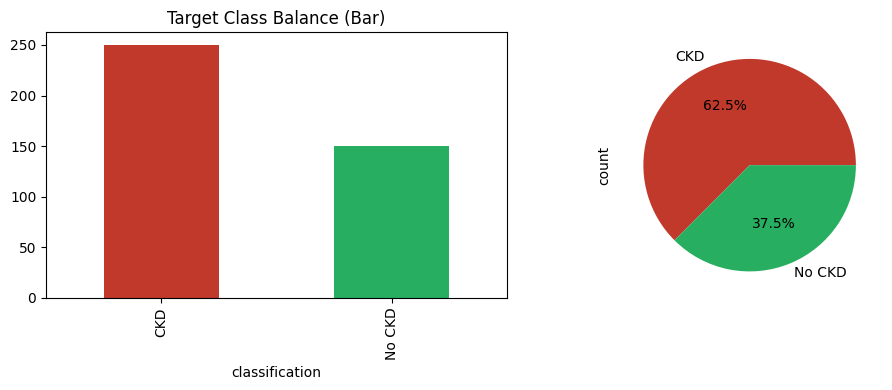

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["classification"].map({"ckd": "CKD", "notckd": "No CKD"}).value_counts().plot(
    kind="bar", color=["#c0392b", "#27ae60"], ax=axes[0]
)
axes[0].set_ylabel("")
axes[0].set_title("Target Class Balance (Bar)")

df["classification"].map({"ckd": "CKD", "notckd": "No CKD"}).value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#c0392b", "#27ae60"], ax=axes[1]
)
ax.set_ylabel("")
ax.set_title("Target Class Balance")
plt.tight_layout()
plt.show()

Skew Plot

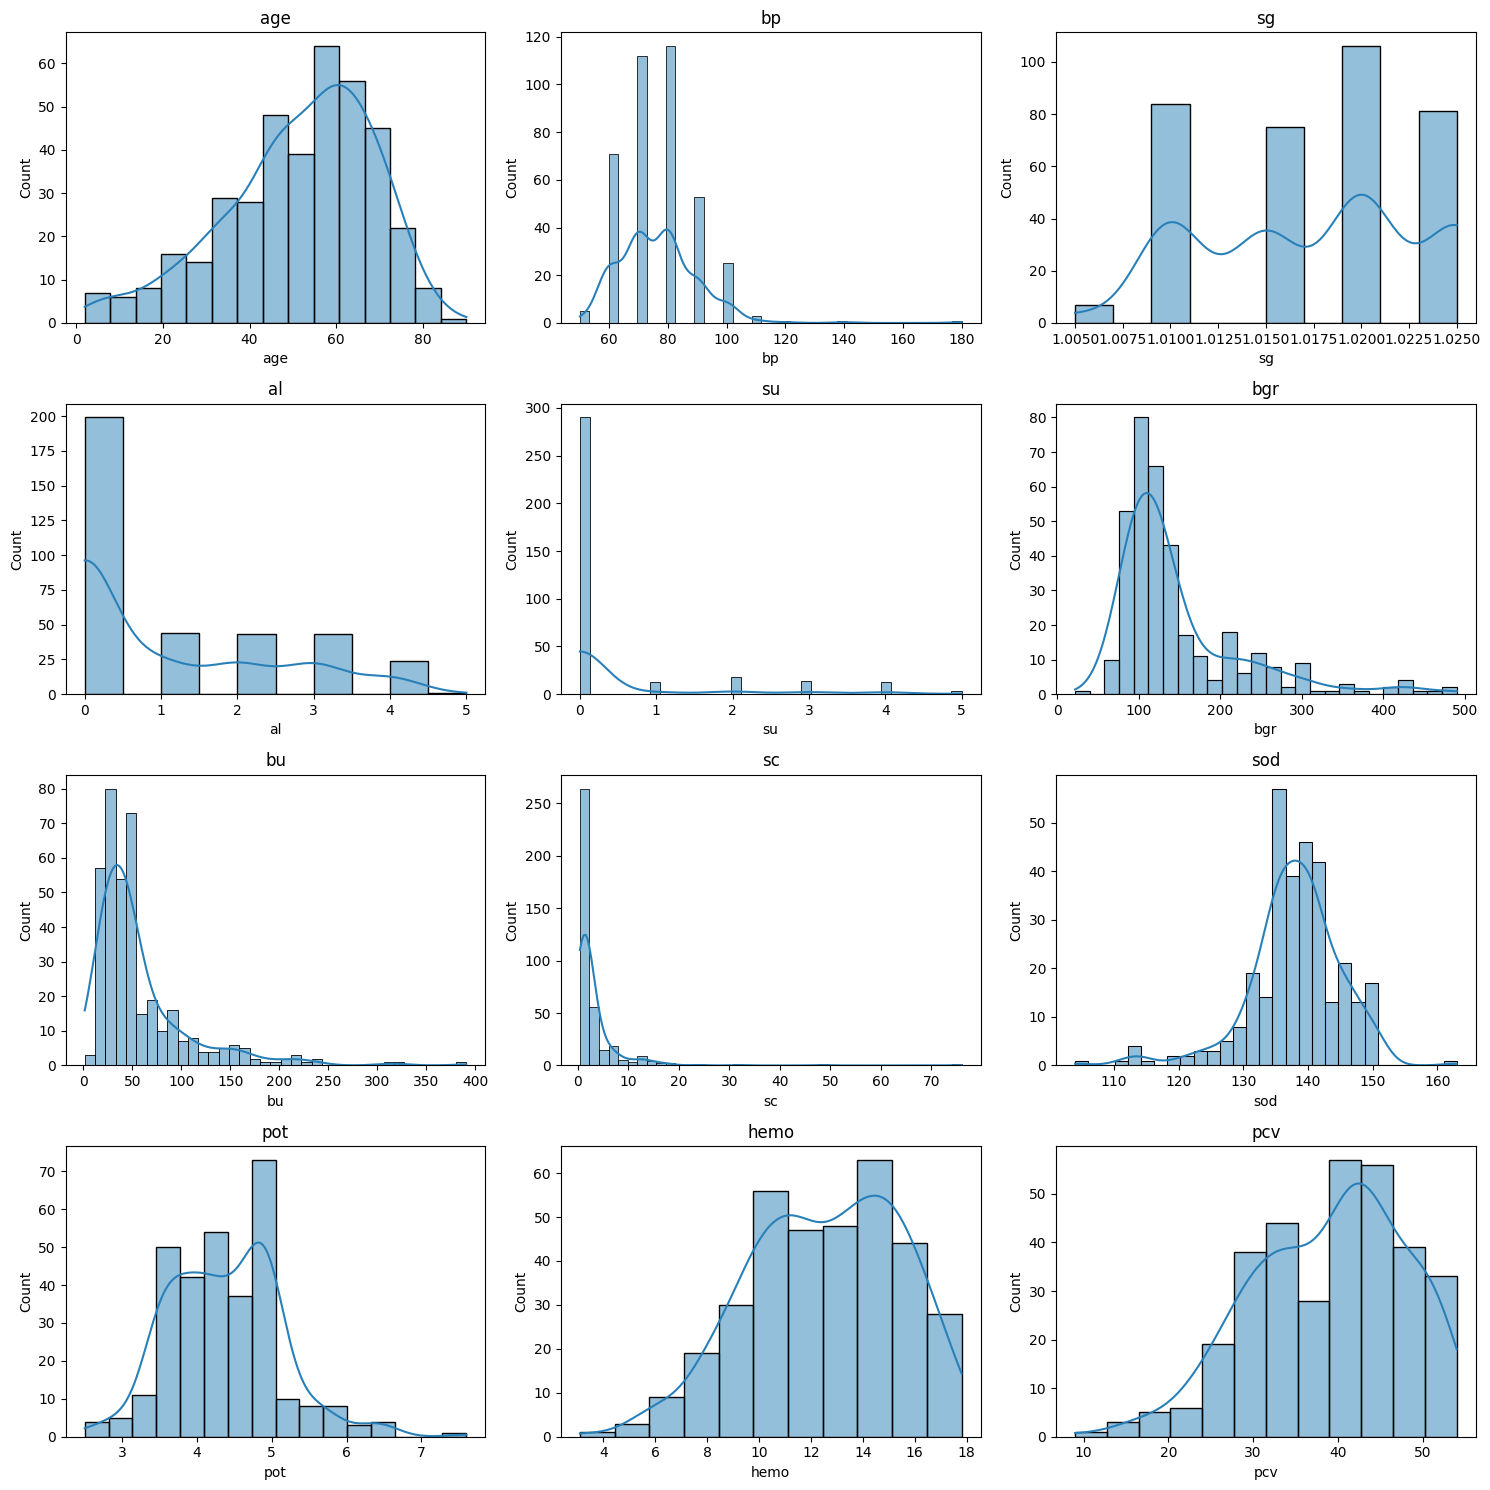

In [77]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2980b9")
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Boxplot

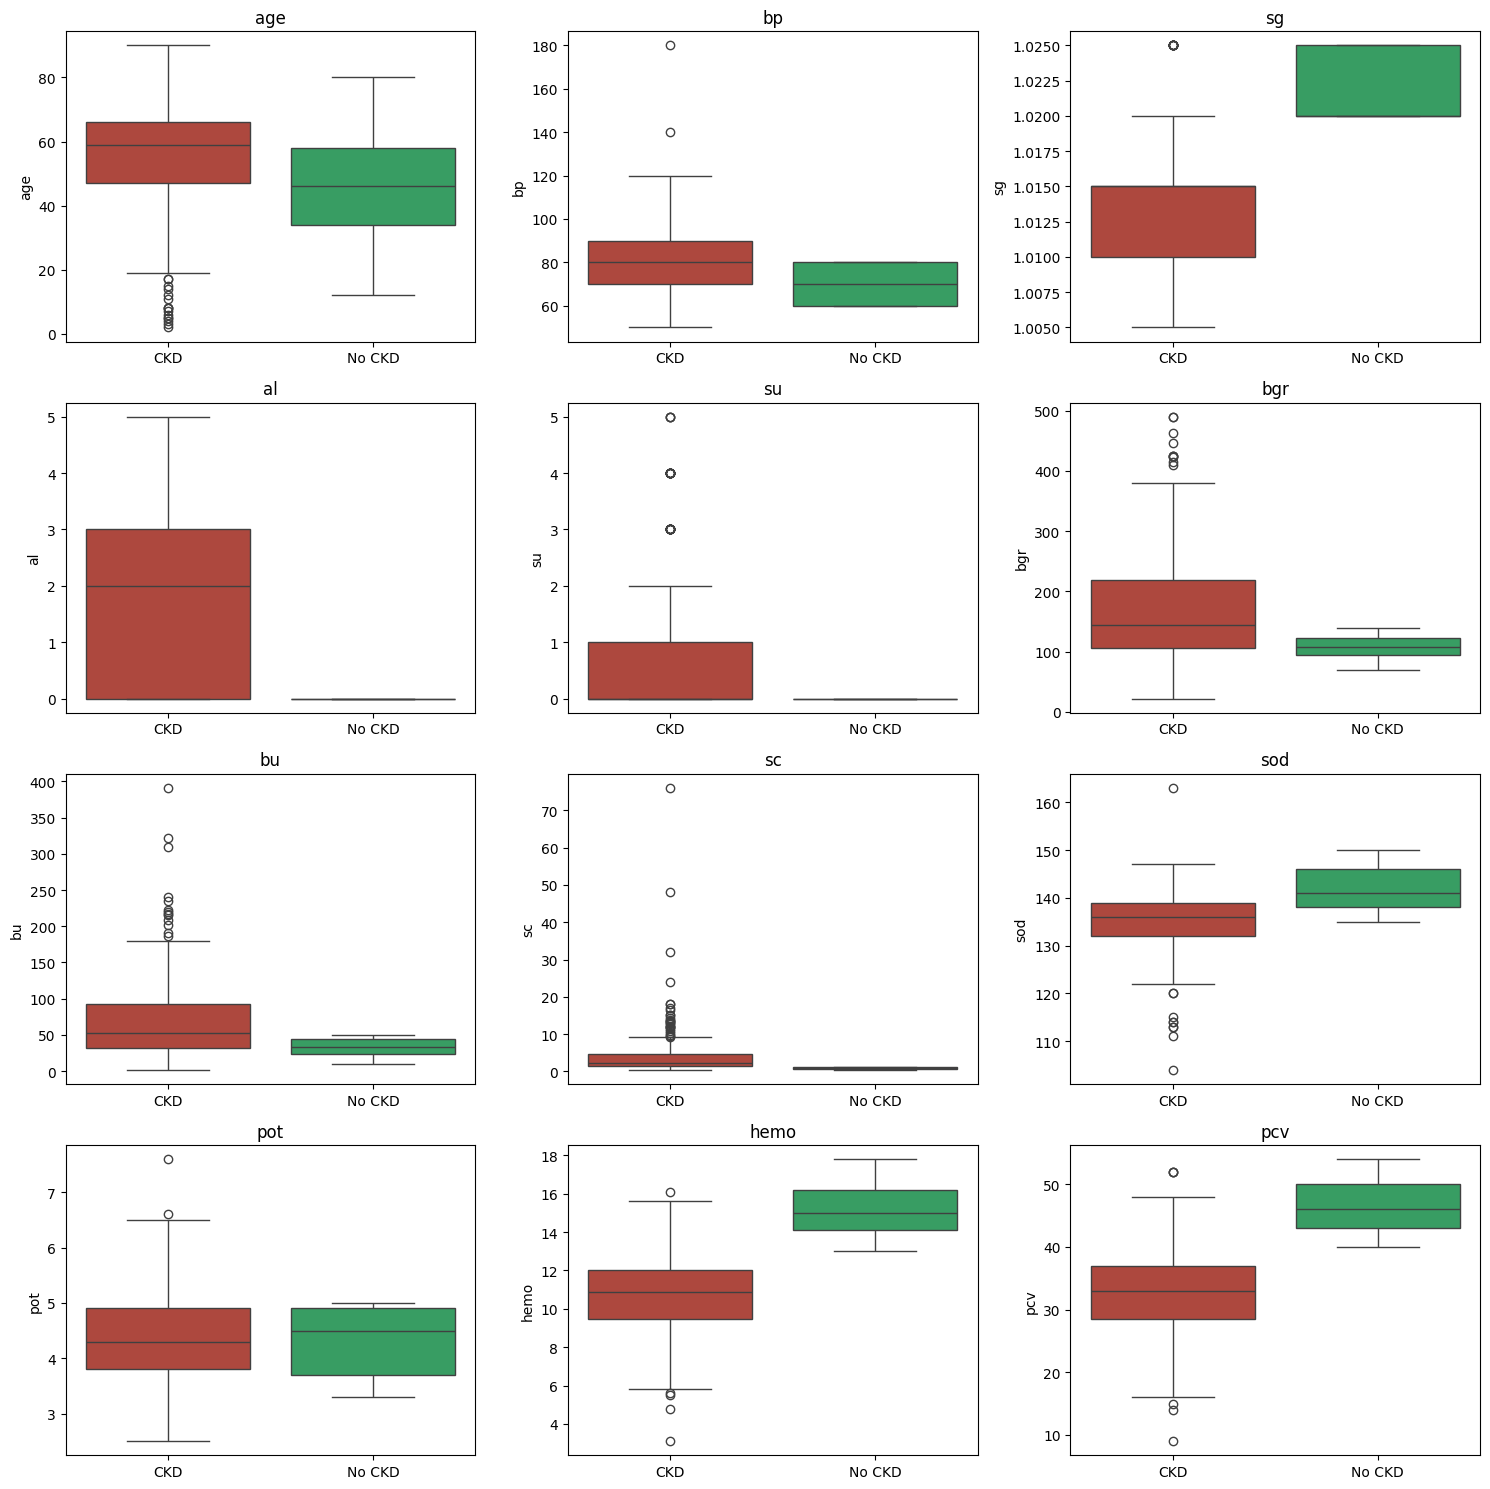

In [78]:
target_labels = df["classification"].map({"ckd": "CKD", "notckd": "No CKD"})

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=target_labels, y=df[col], hue=target_labels, ax=ax,
                palette={"No CKD": "#27ae60", "CKD": "#c0392b"}, legend=False)
    ax.set_xlabel("")
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Correlation Heatmap

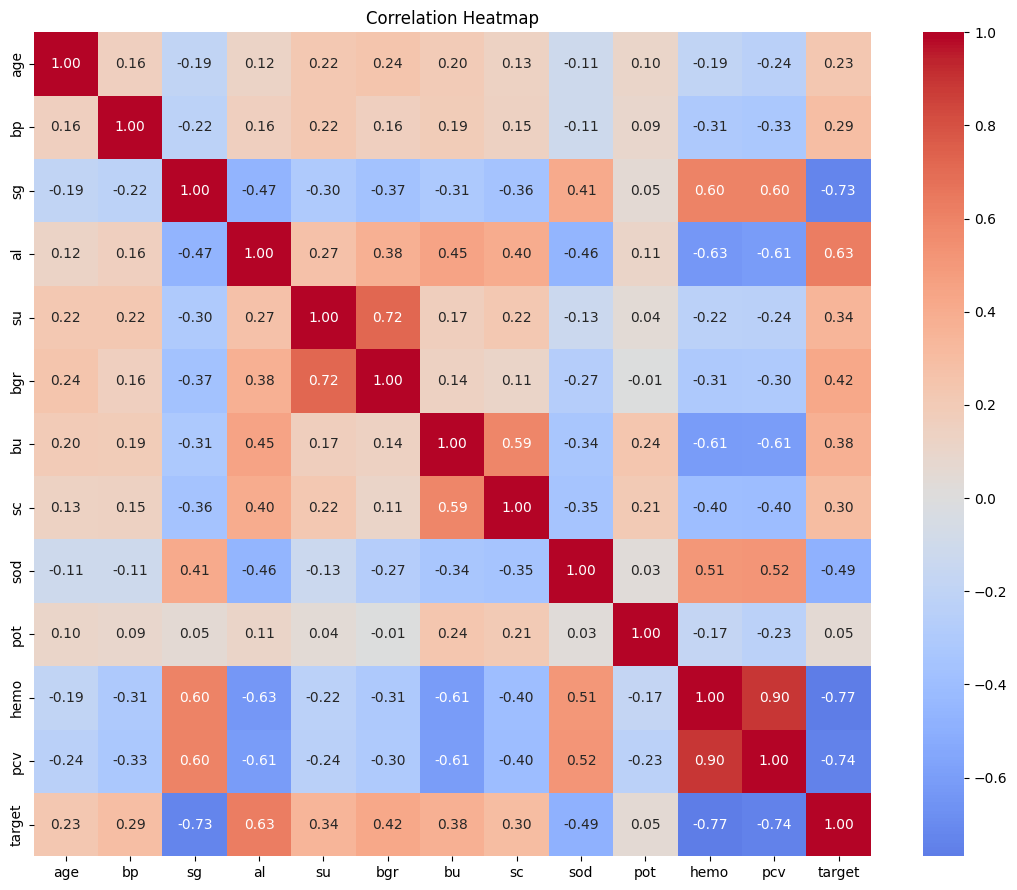

In [79]:
# Correlation heatmap -- classification (ckd/notckd) needs to be numeric 1/0 to correlate meaningfully.
# .assign() builds a throwaway frame just for this calculation; nothing persists to df.
corr = df[num_cols].assign(target=(df["classification"] == "ckd").astype(int)).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [80]:
for col in ["pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]:
    print(col, df[col].unique())

pc ['normal' 'abnormal' nan]
pcc ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
htn ['yes' 'no' nan]
dm ['yes' 'no' nan]
cad ['no' 'yes' nan]
appet ['good' 'poor' nan]
pe ['no' 'yes' nan]
ane ['no' 'yes' nan]


In [81]:
bin_map_yesno = {"yes": 1, "no": 0}
df["pc_abnormal"]  = df["pc"].map({"normal": 0, "abnormal": 1})
df["pcc_present"]  = df["pcc"].map({"notpresent": 0, "present": 1})
df["ba_present"]   = df["ba"].map({"notpresent": 0, "present": 1})
df["htn_yes"]      = df["htn"].map({"yes": 1, "no": 0})
df["dm_yes"]       = df["dm"].map({"yes": 1, "no": 0})
df["cad_yes"]      = df["cad"].map({"yes": 1, "no": 0})
df["appet_good"]   = df["appet"].map({"good": 1, "poor": 0})
df["pe_yes"]       = df["pe"].map({"yes": 1, "no": 0})
df["ane_yes"]      = df["ane"].map({"yes": 1, "no": 0})

df = df.drop(columns=["pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"])

In [82]:
df["classification"] = df["classification"].map({"ckd": 1, "notckd": 0})

In [83]:
df.head()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,...,classification,pc_abnormal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_good,pe_yes,ane_yes
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,...,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,...,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [84]:
skewed_cols = ["bgr", "bu", "sc", "bp"]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [85]:
df.head()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,...,classification,pc_abnormal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_good,pe_yes,ane_yes
0,48.0,4.394449,1.020,1.0,0.0,4.804021,3.610918,0.788457,NaN,NaN,...,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,7.0,3.931826,1.020,4.0,0.0,NaN,2.944439,0.587787,NaN,NaN,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,62.0,4.394449,1.010,2.0,3.0,6.049733,3.988984,1.029619,NaN,NaN,...,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,48.0,4.262680,1.005,4.0,0.0,4.770685,4.043051,1.568616,111.0,2.5,...,1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,51.0,4.394449,1.010,2.0,0.0,4.672829,3.295837,0.875469,NaN,NaN,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Pipeline

In [86]:
X = df.drop(columns=["classification"])
y = df["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(320, 21) (80, 21)


In [87]:
binary_cols = ["pc_abnormal", "pcc_present", "ba_present", "htn_yes",
               "dm_yes", "cad_yes", "appet_good", "pe_yes", "ane_yes"]
cont_cols = [c for c in X_train.columns if c not in binary_cols]

impute_medians = X_train[cont_cols].median()
impute_modes = X_train[binary_cols].mode().iloc[0]

X_train = X_train.copy()
X_test = X_test.copy()
X_train[cont_cols] = X_train[cont_cols].fillna(impute_medians)
X_test[cont_cols] = X_test[cont_cols].fillna(impute_medians)
X_train[binary_cols] = X_train[binary_cols].fillna(impute_modes)
X_test[binary_cols] = X_test[binary_cols].fillna(impute_modes)

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cross-validation evaluation

In [89]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
}

In [91]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy"]

cv_results = {}
print(f"{'Model':<20}{'ROC-AUC':>12}{'F1':>12}{'Accuracy':>12}")
print("-" * 56)
for name, clf in models.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)  # <- was X_train
    cv_results[name] = scores
    print(f"{name:<20}{scores['test_roc_auc'].mean():>12.4f}"
          f"{scores['test_f1'].mean():>12.4f}{scores['test_accuracy'].mean():>12.4f}")

best_name = max(cv_results, key=lambda n: cv_results[n]["test_f1"].mean())
print(f"\nBest model by mean CV F1: {best_name}")

Model                    ROC-AUC          F1    Accuracy
--------------------------------------------------------
LogisticRegression        1.0000      0.9924      0.9906
RandomForest              0.9996      0.9901      0.9875
XGBoost                   0.9981      0.9849      0.9812

Best model by mean CV F1: LogisticRegression


In [92]:
best_model = models[best_name]
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No CKD", "CKD"]))

Accuracy : 0.9875
ROC-AUC  : 1.0000
F1       : 0.9899

              precision    recall  f1-score   support

      No CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



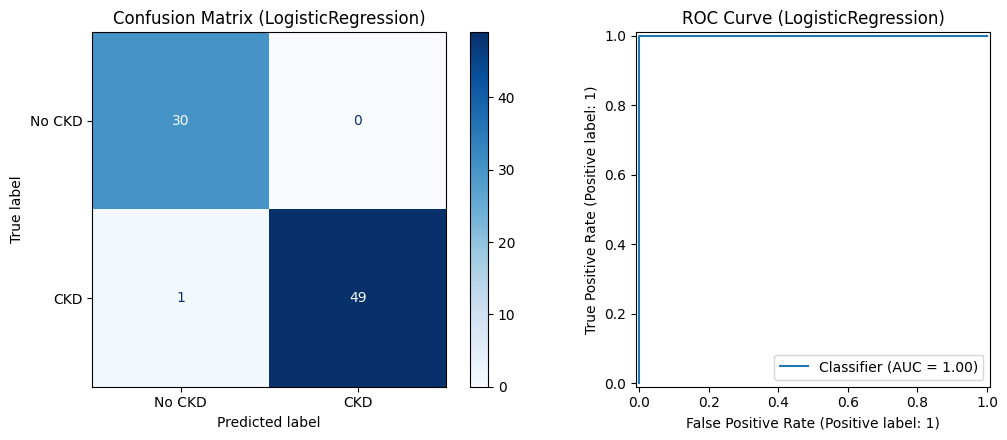

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No CKD", "CKD"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix ({best_name})")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve ({best_name})")
plt.tight_layout()
plt.show()

Saving Pipeline

In [94]:
kidney_model = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler,
    "feature_columns": list(X_train.columns),
    "binary_cols": binary_cols,
    "cont_cols": cont_cols,
    "skewed_cols": skewed_cols,
    "impute_medians": impute_medians.to_dict(),
    "impute_modes": impute_modes.to_dict(),
    "drop_cols": ["id", "rbc", "wc", "rc"],
    "binary_value_maps": {
        "pc": {"normal": 0, "abnormal": 1},
        "pcc": {"notpresent": 0, "present": 1},
        "ba": {"notpresent": 0, "present": 1},
        "htn": {"yes": 1, "no": 0}, "dm": {"yes": 1, "no": 0},
        "cad": {"yes": 1, "no": 0}, "appet": {"good": 1, "poor": 0},
        "pe": {"yes": 1, "no": 0}, "ane": {"yes": 1, "no": 0},
    },
    "sod_pot_outlier_bounds": {"sod_min": 50, "pot_max": 15},  
}
joblib.dump(kidney_model, "kidney_model.joblib")

['kidney_model.joblib']